In [11]:
# coding: utf-8
""" demo on dynamic eit using JAC method """
# Copyright (c) Benyuan Liu. All Rights Reserved.
# Distributed under the (new) BSD License. See LICENSE.txt for more info.
from __future__ import absolute_import, division, print_function

import matplotlib.pyplot as plt
import numpy as np
import pyeit.eit.jac as jac
import pyeit.mesh as mesh
from pyeit.eit.fem import EITForward
from pyeit.eit.interp2d import sim2pts
from pyeit.mesh.shape import thorax
import pyeit.eit.protocol as protocol
from pyeit.mesh.wrapper import PyEITAnomaly_Circle

In [12]:
""" 0. build mesh """
n_el = 16  # nb of electrodes
use_customize_shape = False
if use_customize_shape:
    # Mesh shape is specified with fd parameter in the instantiation, e.g : fd=thorax
    mesh_obj = mesh.create(n_el, h0=0.1, fd=thorax)
else:
    mesh_obj = mesh.create(n_el, h0=0.1)

# extract node, element, alpha
pts = mesh_obj.node
tri = mesh_obj.element
x, y = pts[:, 0], pts[:, 1]

In [40]:
""" 1. problem setup """
# mesh_obj["alpha"] = np.random.rand(tri.shape[0]) * 200 + 100 # NOT USED
anomaly = PyEITAnomaly_Circle(center=[0.5, 0.5], r=0.1, perm=1000.0)
# anomaly = [
#     PyEITAnomaly_Circle(center=[0.4, 0], r=0.1, perm=10.0),
#     PyEITAnomaly_Circle(center=[-0.4, 0], r=0.1, perm=10.0),
#     PyEITAnomaly_Circle(center=[0, 0.5], r=0.1, perm=0.1),
#     PyEITAnomaly_Circle(center=[0, -0.5], r=0.1, perm=0.1),
# ]
mesh_new = mesh.set_perm(mesh_obj, anomaly=anomaly)


In [45]:
""" 2. FEM simulation """
# setup EIT scan conditions
protocol_obj = protocol.create(n_el, dist_exc=8, step_meas=1, parser_meas="std")

# calculate simulated data
fwd = EITForward(mesh_obj, protocol_obj)
v0 = fwd.solve_eit()
v1 = fwd.solve_eit(perm=mesh_new.perm)

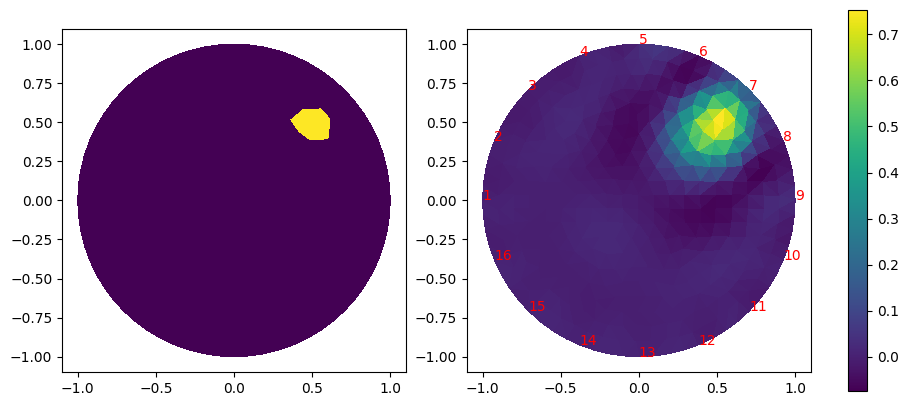

In [46]:
""" 3. JAC solver """
# Note: if the jac and the real-problem are generated using the same mesh,
# then, data normalization in solve are not needed.
# However, when you generate jac from a known mesh, but in real-problem
# (mostly) the shape and the electrode positions are not exactly the same
# as in mesh generating the jac, then data must be normalized.
eit = jac.JAC(mesh_obj, protocol_obj)
eit.setup(p=0.5, lamb=0.01, method="kotre", perm=1, jac_normalized=True)
ds = eit.solve(v1, v0, normalize=True)
ds_n = sim2pts(pts, tri, np.real(ds))

# plot ground truth
fig, axes = plt.subplots(1, 2, constrained_layout=True)
fig.set_size_inches(9, 4)

ax = axes[0]
delta_perm = mesh_new.perm - mesh_obj.perm
im = ax.tripcolor(x, y, tri, np.real(delta_perm), shading="flat")
ax.set_aspect("equal")

# plot EIT reconstruction
ax = axes[1]
im = ax.tripcolor(x, y, tri, ds_n, shading="flat")
for i, e in enumerate(mesh_obj.el_pos):
    ax.annotate(str(i + 1), xy=(x[e], y[e]), color="r")
ax.set_aspect("equal")

fig.colorbar(im, ax=axes.ravel().tolist())
# plt.savefig('../doc/images/demo_jac.png', dpi=96)
plt.show()

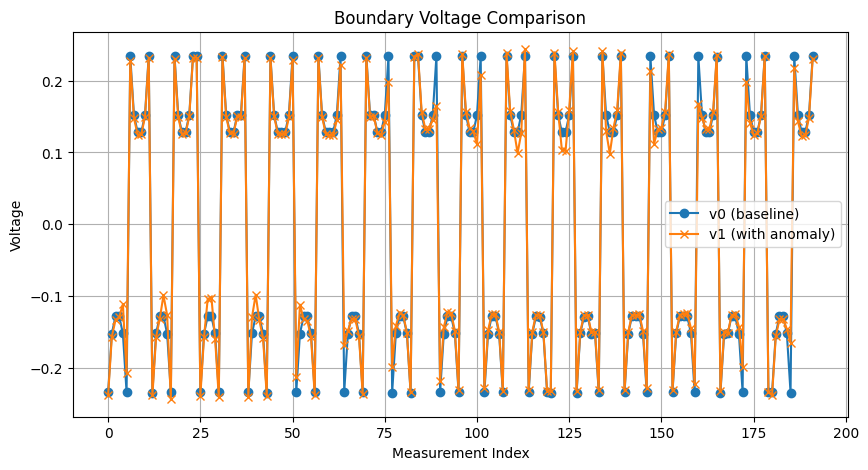

In [47]:
""" Plot boundary voltages """
plt.figure(figsize=(10,5))

plt.plot(v0, label="v0 (baseline)", marker='o')
plt.plot(v1, label="v1 (with anomaly)", marker='x')

plt.title("Boundary Voltage Comparison")
plt.xlabel("Measurement Index")
plt.ylabel("Voltage")
plt.legend()
plt.grid(True)
plt.show()

In [48]:
# reshape v0 and v1 by excitation
n_exc = protocol_obj.ex_mat.shape[0]
n_meas = len(v0) // n_exc

v0_mat = np.asarray(v0).reshape(n_exc, n_meas)
v1_mat = np.asarray(v1).reshape(n_exc, n_meas)

print("Number of excitations:", n_exc)
print("Measurements per excitation:", n_meas)
print("Total measurements:", len(v0))

Number of excitations: 16
Measurements per excitation: 12
Total measurements: 192


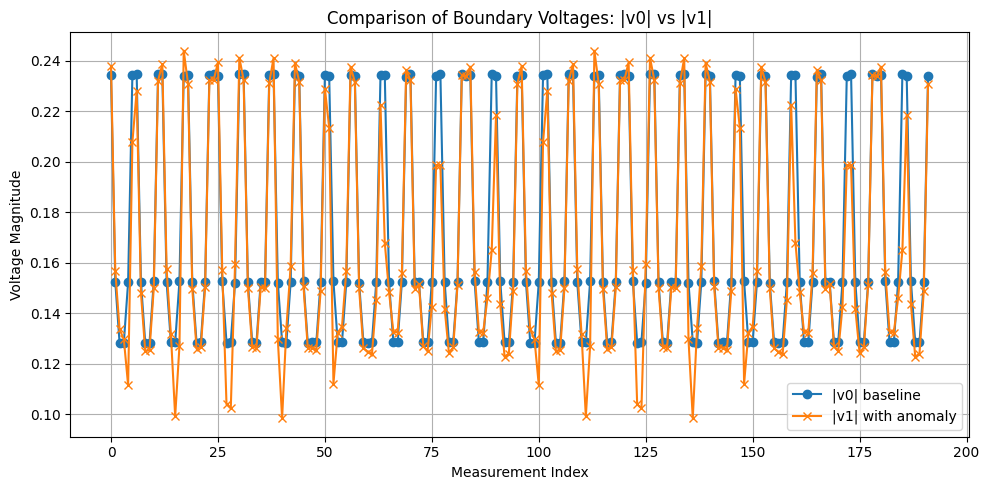

In [49]:
plt.figure(figsize=(10, 5))

plt.plot(np.abs(v0), marker='o', label='|v0| baseline')
plt.plot(np.abs(v1), marker='x', label='|v1| with anomaly')

plt.title("Comparison of Boundary Voltages: |v0| vs |v1|")
plt.xlabel("Measurement Index")
plt.ylabel("Voltage Magnitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

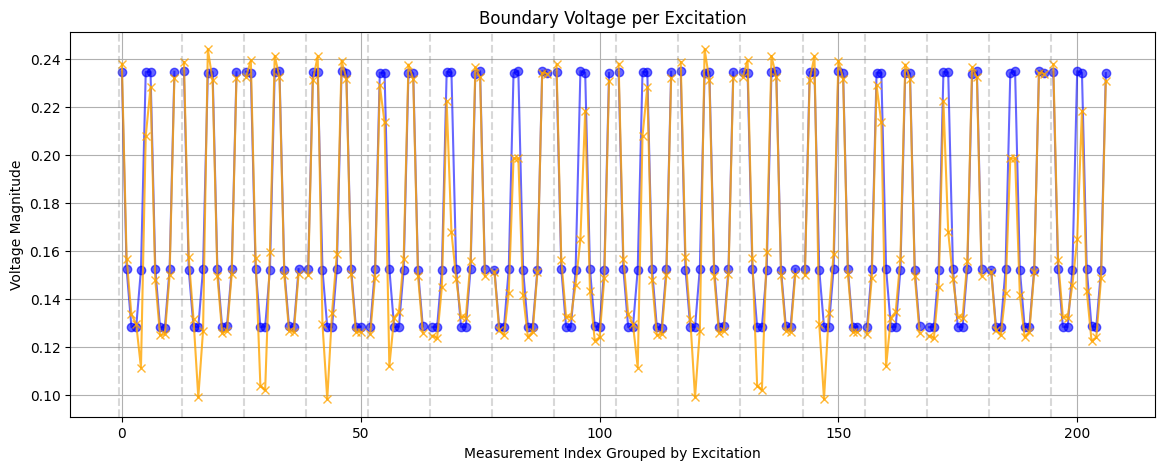

In [19]:
plt.figure(figsize=(14, 5))

for i in range(n_exc):
    x_idx = np.arange(n_meas) + i * (n_meas + 1)

    plt.plot(
        x_idx,
        np.abs(v0_mat[i]),
        marker='o',
        color='blue',
        alpha=0.6
    )

    plt.plot(
        x_idx,
        np.abs(v1_mat[i]),
        marker='x',
        color='orange',
        alpha=0.8
    )

    plt.axvline(i * (n_meas + 1) - 0.5, color='gray', linestyle='--', alpha=0.3)

plt.title("Boundary Voltage per Excitation")
plt.xlabel("Measurement Index Grouped by Excitation")
plt.ylabel("Voltage Magnitude")
plt.grid(True)
plt.show()

In [20]:
print("len(v0):", len(v0))
print("ex_mat shape:", protocol_obj.ex_mat.shape)
print("meas_mat shape:", protocol_obj.meas_mat.shape)

len(v0): 192
ex_mat shape: (16, 2)
meas_mat shape: (16, 12, 2)
